In [45]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [46]:
import matplotlib 
matplotlib.__version__

'3.9.2'

In [47]:
#Определяем систему
#case 1 -- u = pi/2
#case 2 -- u = -pi/2
def f(x1, x2, case = 1):
    dx1 = x2
    dx2 = (-np.cos(x1)) if case == 1 else (np.cos(x1))
    return dx1, dx2

In [48]:
#Первые интегралы для двух случаев 
def H(x1, x2, case=1):
    return 0.5*x2**2 + (np.sin(x1) if case == 1 else -np.sin(x1))

In [49]:
# один шаг метода Рунге-Кутты 4 порядка
def rk4_step(x1, x2, dt, case):
    k1_1, k1_2 = f(x1, x2, case)
    k2_1, k2_2 = f(x1 + 0.5 * dt * k1_1, x2 + 0.5 * dt * k1_2, case)
    k3_1, k3_2 = f(x1 + 0.5 * dt * k2_1, x2 + 0.5 * dt * k2_2, case)
    k4_1, k4_2 = f(x1 + dt * k3_1, x2 + dt * k3_2, case)

    x1n = x1 + (dt/6.0) * (k1_1 + 2 * k2_1 + 2 * k3_1 + k4_1)
    x2n = x2 + (dt/6.0) * (k1_2 + 2 * k2_2 + 2 * k3_2 + k4_2)
    return x1n, x2n

In [50]:
#Интегрируем 
def integrate_traj(x10, x20, T = 20.0, dt = 0.01, case = 1):
    n = int( T / dt)
    x1 = np.empty(n + 1)
    x2 = np.empty(n + 1)
    x1[0], x2[0] = x10, x20
    for i in range(n):
        x1[i + 1], x2[i + 1] = rk4_step(x1[i], x2[i], dt, case)
    return x1, x2

In [51]:
#Рисуем фазовые портреты 
def plot_phase(case = 1, x1_lim = (-2*np.pi, 2*np.pi), x2_lim = (-3, 3), grid_n = 200):

    x1 = np.linspace(*x1_lim, grid_n)
    x2 = np.linspace(*x2_lim, grid_n)
    X1, X2 = np.meshgrid(x1, x2)

    U, V = f(X1, X2, case)

    plt.figure(figsize = (8, 5))

    color = "tab:blue" if case == 1 else "tab:red"

    plt.streamplot(X1, X2, U, V, density = 1.2, color = color)

    plt.axvline(0, color=color, linewidth = 2)
    plt.axhline(0, color=color, linewidth = 2)


    title = r"$\dot x_1 = x_2,\ \dot x_2 = -\cos x_1$" if case == 1 \
            else r"$\dot x_1 = x_2,\ \dot x_2 = \cos x_1$"

    plt.title(title)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    plt.xlim(x1_lim)
    plt.ylim(x2_lim)
    plt.grid(True, alpha = 0.3)
    plt.tight_layout()
    plt.show()

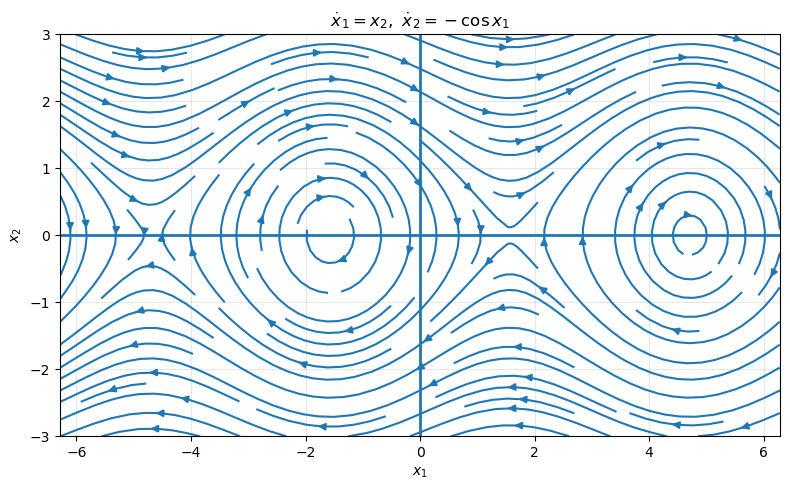

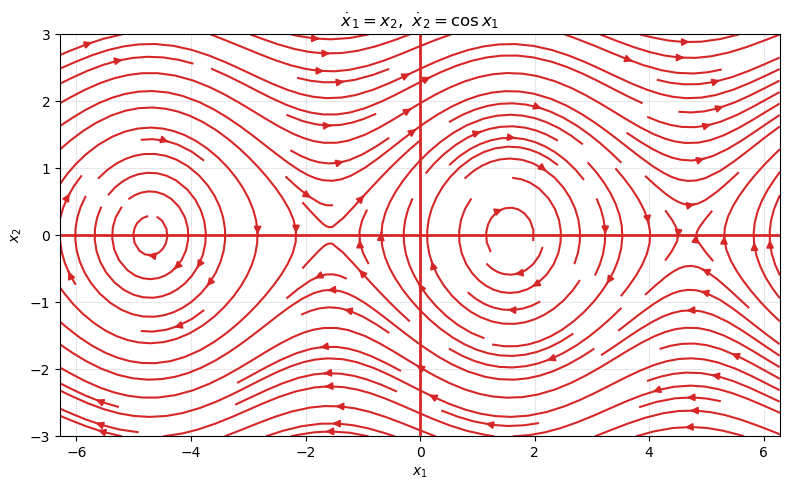

In [52]:
plot_phase(case = 1)  
plot_phase(case = 2) 

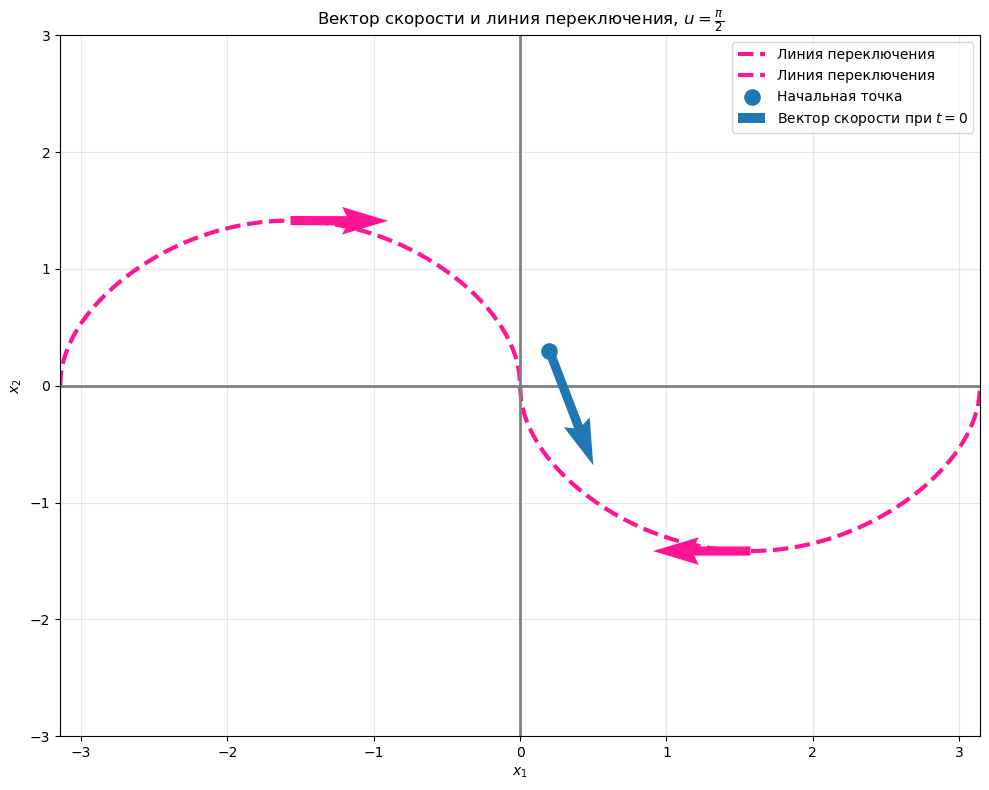

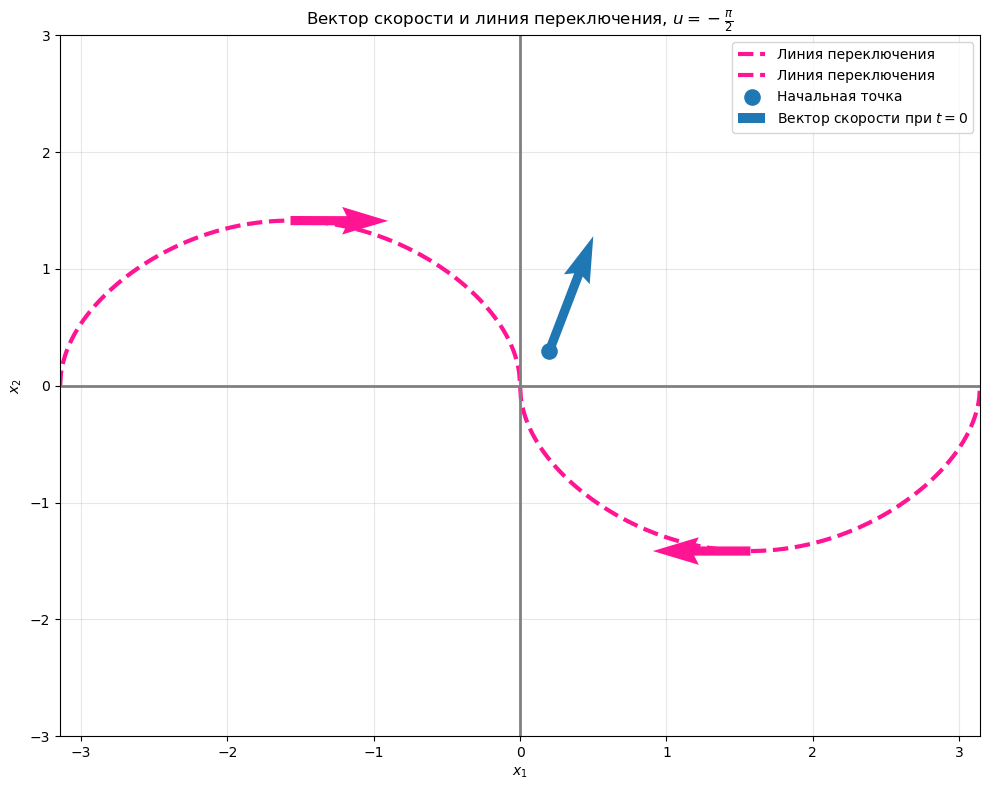

In [53]:
def plot_initial_velocity_vector(case, x10 = 0.2, x20 = 0.3, x1_lim = (-np.pi, np.pi), x2_lim = (-3, 3)):

    dx1, dx2 = f(x10, x20, case)

    plt.figure(figsize = (10, 8))

   #---------------------------------------------------------------------------------------------
    #Отдельно выделяем линию переключения
    x_left = np.linspace(-np.pi, 0, 600)
    y_left = np.sqrt(np.maximum(0, -2 * np.sin(x_left)))

    plt.plot(x_left,  y_left,
            color = "deeppink", linewidth = 3, linestyle="--",
            label = "Линия переключения")

    x_right = np.linspace(0, np.pi, 600)
    y_right = -np.sqrt(np.maximum(0, 2 * np.sin(x_right)))

    plt.plot(x_right, y_right,
             color = "deeppink", linewidth = 3, linestyle="--",
             label = "Линия переключения")

    #СТрелки на линии переключения
    # левая ветвь 
    i = len(x_left) // 2
    tx = x_left[i + 1] - x_left[i]
    ty = y_left[i + 1] - y_left[i]

    norm = np.sqrt(tx**2 + ty**2)
    tx, ty = tx/norm, ty/norm   

    plt.quiver(
        x_left[i], y_left[i],
        tx, ty,
        angles = "xy",
        scale_units = "xy",
        scale = 1.5,       
        color = "deeppink",
        width = 0.01,
        zorder = 8)

    # правая ветвь 
    i = len(x_right) // 2
    tx = x_right[i - 1] - x_right[i]
    ty = y_right[i - 1] - y_right[i]

    norm = np.sqrt(tx**2 + ty**2)
    tx, ty = tx/norm, ty/norm

    plt.quiver(
        x_right[i], y_right[i],
        tx, ty,
        angles = "xy",
        scale_units = "xy",
        scale = 1.5,        
        color = "deeppink",
        width = 0.01,
        zorder = 8)

    #---------------------------------------------------------------------------------------------
    #Начальная точка
    plt.scatter(x10, x20, color = "tab:blue", s = 120, zorder = 5, label = "Начальная точка")

    #---------------------------------------------------------------------------------------------
    #Вектор скорости
    plt.quiver(
        x10, x20, dx1, dx2,
        angles = "xy",
        scale_units = "xy",
        scale = 1,
        color = "tab:blue",
        width = 0.01,
        zorder = 6,
        label = "Вектор скорости при $t=0$")
    
    #---------------------------------------------------------------------------------------------
    #оси
    plt.axvline(0, color = "gray", linewidth = 2)
    plt.axhline(0, color = "gray", linewidth = 2)

    title = (r"Вектор скорости и линия переключения, "
             r"$u=\frac{\pi}{2}$") if case == 1 else \
            (r"Вектор скорости и линия переключения, "
             r"$u=-\frac{\pi}{2}$")

    plt.title(title)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    plt.xlim(*x1_lim)
    plt.ylim(*x2_lim)
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

plot_initial_velocity_vector(case = 1)
plot_initial_velocity_vector(case = 2)


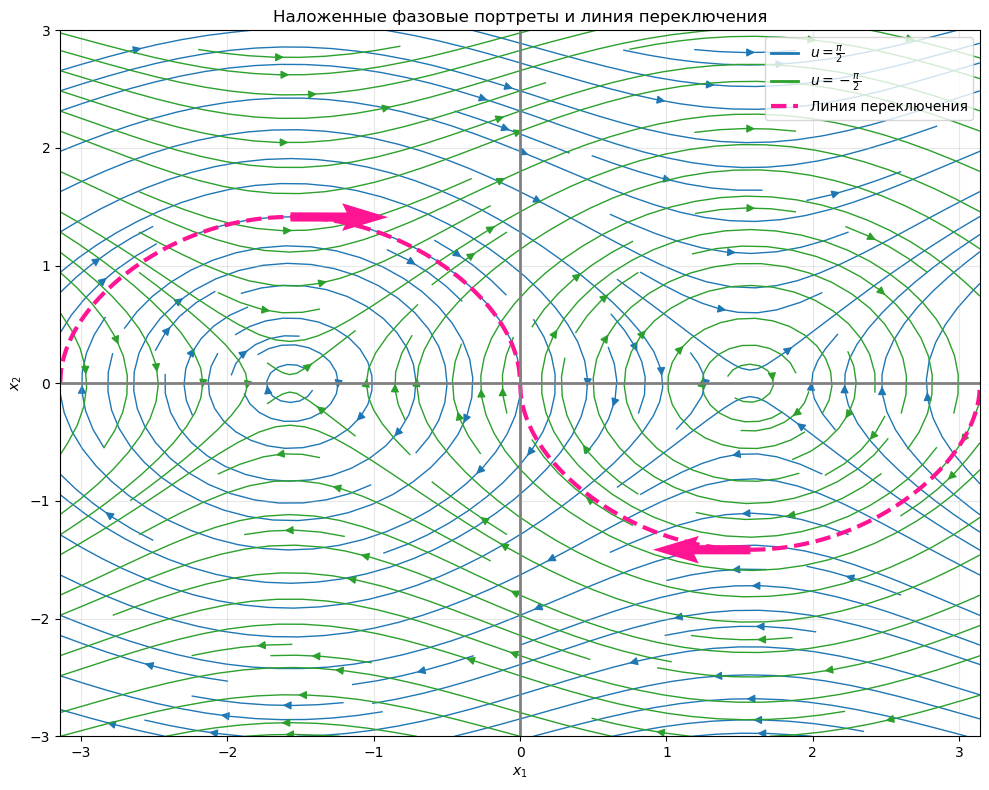

In [54]:
def plot_overlay_phase_portraits_with_switch(x1_lim = (-np.pi, np.pi), x2_lim = (-3, 3), grid_n = 250):

    x1 = np.linspace(*x1_lim, grid_n)
    x2 = np.linspace(*x2_lim, grid_n)
    X1, X2 = np.meshgrid(x1, x2)

    #Два векторных поля
    U1, V1 = f(X1, X2, case=1)
    U2, V2 = f(X1, X2, case=2)

    plt.figure(figsize = (10, 8))

    #---------------------------------------------------------------------------------------------
    #Фазовый портрет u = pi/2
    plt.streamplot(
        X1, X2, U1, V1,
        density = 1.2,
        color = "tab:blue",
        linewidth = 1,
        arrowsize = 1.2,
        zorder = 1)

    #Фазовый портрет u = -pi/2
    plt.streamplot(
        X1, X2, U2, V2,
        density = 1.2,
        color = "tab:green",
        linewidth = 1,
        arrowsize = 1.2,
        zorder = 2)
    
    #---------------------------------------------------------------------------------------------
    #Отдельно выделяем линию переключения
    x_left = np.linspace(-np.pi, 0, 600)
    y_left = np.sqrt(np.maximum(0, -2 * np.sin(x_left)))

    plt.plot(x_left,  y_left,
            color = "deeppink", linewidth = 3, linestyle="--",
            label = "Линия переключения")

    x_right = np.linspace(0, np.pi, 600)
    y_right = -np.sqrt(np.maximum(0, 2 * np.sin(x_right)))

    plt.plot(x_right, y_right,
             color = "deeppink", linewidth = 3, linestyle="--",
             label = "Линия переключения")

    #СТрелки на линии переключения
    # левая ветвь 
    i = len(x_left) // 2
    tx = x_left[i + 1] - x_left[i]
    ty = y_left[i + 1] - y_left[i]

    norm = np.sqrt(tx**2 + ty**2)
    tx, ty = tx/norm, ty/norm   

    plt.quiver(
        x_left[i], y_left[i],
        tx, ty,
        angles = "xy",
        scale_units = "xy",
        scale = 1.5,       
        color = "deeppink",
        width = 0.01,
        zorder = 8)

    # правая ветвь 
    i = len(x_right) // 2
    tx = x_right[i - 1] - x_right[i]
    ty = y_right[i - 1] - y_right[i]

    norm = np.sqrt(tx**2 + ty**2)
    tx, ty = tx/norm, ty/norm

    plt.quiver(
        x_right[i], y_right[i],
        tx, ty,
        angles = "xy",
        scale_units = "xy",
        scale = 1.5,        
        color = "deeppink",
        width = 0.01,
        zorder = 8)
    
    #---------------------------------------------------------------------------------------------
    #оси
    plt.axvline(0, color = "gray", linewidth = 2)
    plt.axhline(0, color = "gray", linewidth = 2)

    #---------------------------------------------------------------------------------------------
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    plt.xlim(*x1_lim)
    plt.ylim(*x2_lim)
    plt.grid(True, alpha = 0.3)

    plt.title("Наложенные фазовые портреты и линия переключения")
    plt.legend(loc = "upper right")
    plt.tight_layout()

    legend_elements = [
        Line2D([0], [0], color = "tab:blue", lw = 2, label = r"$u=\frac{\pi}{2}$"),
        Line2D([0], [0], color = "tab:green", lw = 2, label = r"$u=-\frac{\pi}{2}$"),
        Line2D([0], [0], color = "deeppink", lw = 3, ls = "--", label = "Линия переключения")]

    plt.legend(handles = legend_elements, loc = "upper right")

    plt.show()

plot_overlay_phase_portraits_with_switch()


In [55]:
# Правая ветвь линии переключения: g = 0, которая нужна для построения траектории
def g_switch(x1, x2):
    return x2**2 - 2 * np.sin(x1)

def switching_point(x10 = 0.2, x20 = 0.3):
    
    C_plus = 0.5 * x20**2 + np.sin(x10)

    #Из условий в точке переключения:
    # x2s^2/2 - sin(x1s) = 0  и  x2s^2/2 + sin(x1s) = C_plus
    # => 2 sin(x1s) = C_plus
    s = 0.5 * C_plus

    #Две ветви решения для x1s: arcsin(s) и pi - arcsin(s)
    a = np.arcsin(s)
    x1s_candidates = [a, np.pi - a]

    x2s = -np.sqrt(C_plus)

    return C_plus, x1s_candidates, x2s

C_plus, x1s_candidates, x2s = switching_point()
print("C_plus =", C_plus)
print("x1s candidates =", x1s_candidates)
print("x2s =", x2s)

print("Нам не подходит большее значение x1s")


C_plus = 0.2436693307950612
x1s candidates = [0.1221381092811355, 3.019454544308658]
x2s = -0.4936287378132084
Нам не подходит большее значение x1s


In [56]:
#Траектория до пересечения с линией переключения, т е u = pi/2 (case = 1)
def integrate_until_switch(x10 = 0.2, x20 = 0.3, dt = 0.001, T = 20.0):
   
    n = int(T/dt)

    t_arr = [0.0]
    x1_arr = [x10]
    x2_arr = [x20]

    x1, x2 = x10, x20
    g_prev = g_switch(x1, x2)

    for k in range(n):
        t = (k + 1) * dt
        x1n, x2n = rk4_step(x1, x2, dt, case=1)
        g_now = g_switch(x1n, x2n)

        if (g_prev == 0) or (g_prev * g_now <= 0):
            if x2n < 0:
                alpha = g_prev / (g_prev - g_now) if (g_prev - g_now) != 0 else 0.0
                ts = t_arr[-1] + alpha * dt
                x1s = x1_arr[-1] + alpha * (x1n - x1_arr[-1])
                x2s = x2_arr[-1] + alpha * (x2n - x2_arr[-1])

                t_arr.append(ts)
                x1_arr.append(x1s)
                x2_arr.append(x2s)
                print(f"k = {k}")
                return np.array(t_arr), np.array(x1_arr), np.array(x2_arr), ts, x1s, x2s

        t_arr.append(t)
        x1_arr.append(x1n)
        x2_arr.append(x2n)

        x1, x2 = x1n, x2n
        g_prev = g_now

    raise RuntimeError("ERRROR: change T or dt!")


In [57]:
#Траектория после пересечения с линией переключения, т е u = -pi/2 (case = 2)
def integrate_to_target_from_switch(x1s, x2s, ts, dt = 0.0001, T = 20.0, eps = 1e-4):
    
    n = int(T/dt)

    t_arr = [ts]
    x1_arr = [x1s]
    x2_arr = [x2s]

    x1, x2 = x1s, x2s

    for k in range(n):
        t = ts + (k + 1) * dt
        x1n, x2n = rk4_step(x1, x2, dt, case=2)

        t_arr.append(t)
        x1_arr.append(x1n)
        x2_arr.append(x2n)

        if (abs(x1n) < eps) and (abs(x2n) < eps):
            tk = t
            return np.array(t_arr), np.array(x1_arr), np.array(x2_arr), tk

        x1, x2 = x1n, x2n

    raise RuntimeError("ERRROR: change T, dt or eps!")


In [58]:
#До линии переключения
t1, x1_1, x2_1, ts, x1s, x2s = integrate_until_switch(dt = 0.01, T = 3.0)
print(f"Точка переключения: ts = {ts:.6f}, x1s = {x1s:.6f}, x2s = {x2s:.6f}")

#После переключения до (0, 0)
t2, x1_2, x2_2, tk = integrate_to_target_from_switch(x1s, x2s, ts, dt = 0.0001, T = 30.0, eps = 1e-4)
print(f"Конечная точка (должна быть (0, 0)): tk = {tk:.6f}, x1(tk) = {x1_2[-1]:.10f}, x2(tk) = {x2_2[-1]:.10f}")


k = 81
Точка переключения: ts = 0.812697, x1s = 0.122138, x2s = -0.493609
Конечная точка (должна быть (0, 0)): tk = 1.306997, x1(tk) = 0.0000099995, x2(tk) = -0.0000464293


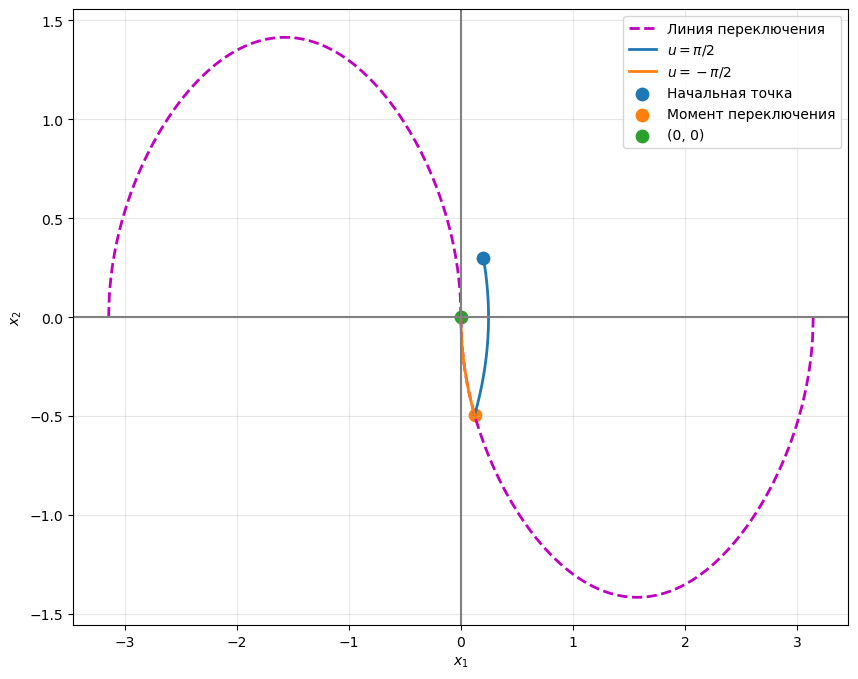

In [59]:
#Рисуем траекторию движения
plt.figure(figsize = (10, 8))

x_left = np.linspace(-np.pi, 0, 600)
y_left = np.sqrt(np.maximum(0, -2 * np.sin(x_left)))
plt.plot(x_left, y_left, "m--", lw = 2)

x_right = np.linspace(0, np.pi, 600)
y_right = -np.sqrt(np.maximum(0, 2 * np.sin(x_right)))
plt.plot(x_right, y_right, "m--", lw = 2, label = "Линия переключения")

plt.plot(x1_1, x2_1, lw = 2, label = r"$u=\pi/2$")
plt.plot(x1_2, x2_2, lw = 2, label = r"$u=-\pi/2$")

plt.scatter([0.2],[0.3], s = 80, label = "Начальная точка")
plt.scatter([x1s],[x2s], s = 80, label = "Момент переключения")
plt.scatter([0],[0], s = 80, label = "(0, 0)")

plt.axvline(0, color = "gray")
plt.axhline(0, color = "gray")
plt.grid(True, alpha = 0.3)
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.legend()
plt.show()


In [60]:
#Функция возмущения
def nu(t):
  return 0.1 * np.exp(-t) * np.cos(4 * t)

In [61]:
def rk4_step_perturbed(x1, x2, t, dt, case):

    def f1(x1, x2, t):
        return x2

    def f2(x1, x2, t):
        if case == 1:
            return -np.cos(x1) + nu(t)
        elif case == 2:
            return  np.cos(x1) + nu(t)
        else:
            raise ValueError("Неверное значение case")

    k1_1 = f1(x1, x2, t)
    k1_2 = f2(x1, x2, t)

    k2_1 = f1(x1 + 0.5 * dt * k1_1, x2 + 0.5 * dt * k1_2, t + 0.5 * dt)
    k2_2 = f2(x1 + 0.5 * dt * k1_1, x2 + 0.5 * dt * k1_2, t + 0.5 * dt)

    k3_1 = f1(x1 + 0.5 * dt * k2_1, x2 + 0.5 * dt * k2_2, t + 0.5 * dt)
    k3_2 = f2(x1 + 0.5 * dt * k2_1, x2 + 0.5 * dt * k2_2, t + 0.5 * dt)

    k4_1 = f1(x1 + dt * k3_1, x2 + dt * k3_2, t + dt)
    k4_2 = f2(x1 + dt * k3_1, x2 + dt * k3_2, t + dt)

    x1n = x1 + (dt/6) * (k1_1 + 2 * k2_1 + 2 * k3_1 + k4_1)
    x2n = x2 + (dt/6) * (k1_2 + 2 * k2_2 + 2 * k3_2 + k4_2)

    return x1n, x2n


In [62]:
#Интегрирование возмущенной системы до достижения линии переключения

def integrate_until_switch_perturbed(x10 = 0.2, x20 = 0.3, dt = 1e-3, T = 20.0): 
    
    n = int(T/dt)

    t_arr = [0.0]
    x1_arr = [x10]
    x2_arr = [x20]

    x1, x2 = x10, x20
    g_prev = g_switch(x1, x2)

    for k in range(n):
        t_next = (k + 1) * dt
        x1n, x2n = rk4_step_perturbed(x1, x2, t_arr[-1], dt, case = 1)
        g_now = g_switch(x1n, x2n)

        if (g_prev == 0) or (g_prev * g_now <= 0):
            if x2n < 0:
                alpha = g_prev / (g_prev - g_now) if (g_prev - g_now) != 0 else 0.0
                ts = t_arr[-1] + alpha * dt
                x1s = x1_arr[-1] + alpha * (x1n - x1_arr[-1])
                x2s = x2_arr[-1] + alpha * (x2n - x2_arr[-1])

                t_arr.append(ts)
                x1_arr.append(x1s)
                x2_arr.append(x2s)
                return np.array(t_arr), np.array(x1_arr), np.array(x2_arr), ts, x1s, x2s

        t_arr.append(t_next)
        x1_arr.append(x1n)
        x2_arr.append(x2n)

        x1, x2 = x1n, x2n
        g_prev = g_now

    raise RuntimeError("Не найдено пересечение с линией переключения в возмущённой системе")


In [63]:
#Интегрирование возмущенной системы от линии переключения до момента времени t_k

def integrate_perturbed_after_switch_to_tk(x1s, x2s, ts, tk, dt = 1e-3):

    t_arr = [ts]
    x1_arr = [x1s]
    x2_arr = [x2s]

    x1, x2 = x1s, x2s
    t = ts

    while t < tk - 1e-15:
        dt_eff = min(dt, tk - t)
        x1, x2 = rk4_step_perturbed(x1, x2, t, dt_eff, case = 2)
        t += dt_eff

        t_arr.append(t)
        x1_arr.append(x1)
        x2_arr.append(x2)

    return np.array(t_arr), np.array(x1_arr), np.array(x2_arr)


In [64]:
#tk = 1.307018

#Возмущённая система до линии переключения (u = pi/2)

t1p, x1_1p, x2_1p, ts_p, x1s_p, x2s_p = integrate_until_switch_perturbed(dt = 1e-3, T = 30.0)
print(f"Возмущенная система в момент переключения: ts = {ts_p:.6f}, x1s = {x1s_p:.6f}, x2s = {x2s_p:.6f}")

# После переключения до t_k (u = -pi/2)
t2p, x1_2p, x2_2p = integrate_perturbed_after_switch_to_tk(x1s_p, x2s_p, ts_p, tk, dt = 1e-3)

# Склеиваем траекторию в один массив (для упрощения жизни)
t_p = np.concatenate([t1p, t2p[1:]])
x1_p = np.concatenate([x1_1p, x1_2p[1:]])
x2_p = np.concatenate([x2_1p, x2_2p[1:]])

delta_y = x1_p[-1]  #Промах по y = x1(t_k)
print(f"Возмущенная система в конечный момент: tk = {tk:.6f}: x1 = {x1_p[-1]:.10f}, x2 = {x2_p[-1]:.10f}")
print(f"Delta y = {delta_y:.10f}")



Возмущенная система в момент переключения: ts = 0.829330, x1s = 0.126591, x2s = -0.502501
Возмущенная система в конечный момент: tk = 1.306997: x1 = -0.0025006876, x2 = -0.0326882617
Delta y = -0.0025006876


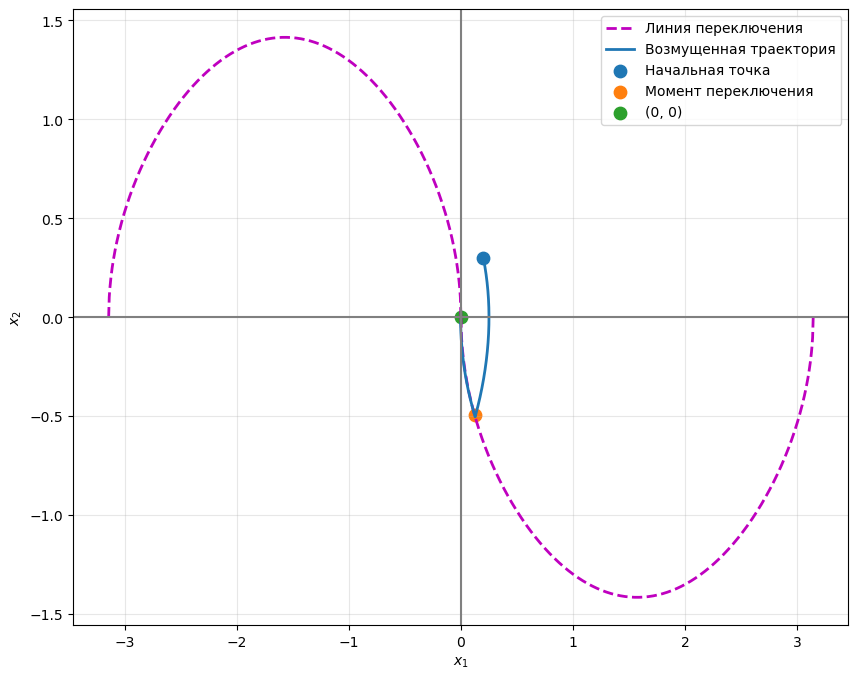

In [65]:
#Рисуем возмущенную траекторию движения
plt.figure(figsize = (10, 8))

x_left = np.linspace(-np.pi, 0, 600)
y_left = np.sqrt(np.maximum(0, -2 * np.sin(x_left)))
plt.plot(x_left, y_left, "m--", lw = 2)

x_right = np.linspace(0, np.pi, 600)
y_right = -np.sqrt(np.maximum(0, 2 * np.sin(x_right)))
plt.plot(x_right, y_right, "m--", lw = 2, label = "Линия переключения")

plt.plot(x1_p, x2_p, lw = 2, label = "Возмущенная траектория")

plt.scatter([0.2],[0.3], s = 80, label = "Начальная точка")
plt.scatter([x1s],[x2s], s = 80, label = "Момент переключения")
plt.scatter([0],[0], s = 80, label = "(0, 0)")

plt.axvline(0, color = "gray")
plt.axhline(0, color = "gray")
plt.grid(True, alpha = 0.3)
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.legend()
plt.show()